<a href="https://colab.research.google.com/github/zheng-anthony/AURA/blob/main/AI4LL_training_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: SECURE DATA INGESTION
# ==========================================
!pip install -q kaggle

import os
from google.colab import files

print("📂 UPLOAD YOUR KAGGLE.JSON FILE NOW:")
uploaded = files.upload()

# Move the Kaggle API key to the secure hidden folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\n📡 DOWNLOADING RDD 2022 DATASET (Slide 3)...")
!kaggle datasets download -d aliabdelmenam/rdd-2022

print("\n📡 DOWNLOADING ANNOTATED POTHOLE DATASET (Slide 5)...")
!kaggle datasets download -d virenbr11/pothole-and-plain-rode-images

print("\n📦 UNZIPPING DATASETS...")
!mkdir -p /content/raw_data
!unzip -q rdd-2022.zip -d /content/raw_data/rdd
!unzip -q pothole-and-plain-rode-images.zip -d /content/raw_data/pothole

print("\n✅ DATA INGESTION COMPLETE!")

📂 UPLOAD YOUR KAGGLE.JSON FILE NOW:


Saving kaggle.json to kaggle.json

📡 DOWNLOADING RDD 2022 DATASET (Slide 3)...
Dataset URL: https://www.kaggle.com/datasets/aliabdelmenam/rdd-2022
License(s): CC-BY-SA-4.0
100% 9.90G/9.90G [01:52<00:00, 94.9MB/s]


📡 DOWNLOADING ANNOTATED POTHOLE DATASET (Slide 5)...
Dataset URL: https://www.kaggle.com/datasets/virenbr11/pothole-and-plain-rode-images
License(s): unknown
100% 241M/241M [00:02<00:00, 123MB/s]


📦 UNZIPPING DATASETS...

✅ DATA INGESTION COMPLETE!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import shutil
import albumentations as A


print("⚙️ INITIALIZING DATA PIPELINE (Merging Custom Splits)...")

BASE_DIR = '/content/raw_data'
OUTPUT_DIR = '/content/yolo_dataset'

# YOLO uses 'val' instead of 'test', so we map your 'test' folders to 'val'
SOURCES = {
    'train': [
        os.path.join(BASE_DIR, 'pothole/My Dataset/train'),
        os.path.join(BASE_DIR, 'rdd/RDD_SPLIT/train')
    ],
    'val': [
        os.path.join(BASE_DIR, 'pothole/My Dataset/test'),
        os.path.join(BASE_DIR, 'rdd/RDD_SPLIT/test')
    ]
}

def process_data(source_folders, split_name):
    print(f"📦 Processing {split_name} split from multiple sources...")
    target_img_dir = os.path.join(OUTPUT_DIR, split_name, 'images')
    target_lab_dir = os.path.join(OUTPUT_DIR, split_name, 'labels')
    os.makedirs(target_img_dir, exist_ok=True)
    os.makedirs(target_lab_dir, exist_ok=True)

    for folder in source_folders:
        if not os.path.exists(folder):
            print(f"⚠️ Warning: Folder not found {folder}")
            continue

        print(f"   -> Scanning {folder}...")
        # os.walk allows us to dig into subfolders in case images/labels are separated
        for root, dirs, files in os.walk(folder):
            for filename in files:
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):

                    img_path = os.path.join(root, filename)

                    # Read and resize to Slide 5 promise (600x400)
                    img = cv2.imread(img_path)
                    if img is None: continue
                    resized_img = cv2.resize(img, (600, 400))
                    cv2.imwrite(os.path.join(target_img_dir, filename), resized_img)

                    # Locate the corresponding .txt label file
                    lab_name = os.path.splitext(filename)[0] + '.txt'

                    # Check the same directory first
                    lab_src = os.path.join(root, lab_name)

                    # If not there, check if it's in a parallel 'labels' directory
                    if not os.path.exists(lab_src):
                        possible_lab_dir = root.replace('images', 'labels')
                        lab_src = os.path.join(possible_lab_dir, lab_name)

                    lab_dst = os.path.join(target_lab_dir, lab_name)

                    if os.path.exists(lab_src):
                        shutil.copy(lab_src, lab_dst)
                    else:
                        # Slide 13: Negative Sampling Injection
                        # If no label exists, create an empty txt file to teach YOLO "this is a healthy road"
                        open(lab_dst, 'w').close()

process_data(SOURCES['train'], 'train')
process_data(SOURCES['val'], 'val')

yaml_content = f"""
path: {OUTPUT_DIR}
train: train/images
val: val/images

names:
  0: D00 (Longitudinal Crack)
  1: D10 (Transverse Crack)
  2: D20 (Alligator Crack)
  3: D40 (Pothole)
"""

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'w') as f:
    f.write(yaml_content)

print("\n✅ DATA PIPELINE FINISHED. DATASETS MERGED & NEGATIVE SAMPLES INJECTED.")

⚙️ INITIALIZING DATA PIPELINE (Merging Custom Splits)...
📦 Processing train split from multiple sources...
   -> Scanning /content/raw_data/pothole/My Dataset/train...
   -> Scanning /content/raw_data/rdd/RDD_SPLIT/train...
📦 Processing val split from multiple sources...
   -> Scanning /content/raw_data/pothole/My Dataset/test...
   -> Scanning /content/raw_data/rdd/RDD_SPLIT/test...

✅ DATA PIPELINE FINISHED. DATASETS MERGED & NEGATIVE SAMPLES INJECTED.


In [ ]:
!pip install -q albumentations

import os
import random
import cv2
import albumentations as A

print("⛈️ INJECTING ALBUMENTATIONS (RAIN/FOG/BLUR) INTO TRAINING SET...")

# We target the YOLO training directory we built in Cell 2
TRAIN_IMG_DIR = "/content/yolo_dataset/train/images"
TRAIN_LAB_DIR = "/content/yolo_dataset/train/labels"

# How many bad-weather images to generate and add to the dataset
NUM_AUGMENTATIONS = 1000

transform = A.Compose(
    [
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7), p=0.4),
            A.MotionBlur(blur_limit=(3, 7), p=0.3),
        ], p=0.5),

        A.OneOf([
            # Fog branch: fog + slight desaturation/brightness shift
            A.Sequential([
                A.RandomFog(fog_coef_range=(0.1, 0.3), alpha_coef=0.08, p=1.0),
                A.RandomBrightnessContrast(brightness_limit=(-0.15, 0.05), contrast_limit=(-0.1, 0.05), p=1.0),
                A.HueSaturationValue(hue_shift_limit=0, sat_shift_limit=(-30, -5), val_shift_limit=0, p=1.0),
            ], p=0.4),

            # Rain branch: rain + its own darker/duller look
            A.Sequential([
                A.RandomRain(drop_length=10, drop_width=1, blur_value=3, p=1.0),
                A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.0), contrast_limit=(-0.1, 0.1), p=1.0),
                A.HueSaturationValue(hue_shift_limit=0, sat_shift_limit=(-20, 0), val_shift_limit=0, p=1.0),
            ], p=0.3),
        ], p=0.4),
    ],
    # MUST specify YOLO format for the bounding boxes so the math stays accurate
    bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]),
)

def load_labels(path):
    boxes, labels = [], []
    if not os.path.exists(path): return boxes, labels
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                labels.append(int(parts[0]))
                boxes.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
    return boxes, labels

images = [f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
# Only grab random samples to augment
samples = random.sample(images, min(NUM_AUGMENTATIONS, len(images)))

success_count = 0
for filename in samples:
    img_path = os.path.join(TRAIN_IMG_DIR, filename)
    label_path = os.path.join(TRAIN_LAB_DIR, os.path.splitext(filename)[0] + ".txt")

    # Read image (OpenCV uses BGR, convert to RGB for Albumentations)
    image = cv2.imread(img_path)
    if image is None: continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes, labels = load_labels(label_path)

    # Skip negative samples (images with no boxes) to prevent Albumentations math errors
    if len(boxes) == 0: continue

    try:
        # Generate the synthetic weather image
        augmented = transform(image=image, bboxes=boxes, class_labels=labels)

        # Convert back to BGR to save using OpenCV
        aug_img_bgr = cv2.cvtColor(augmented["image"], cv2.COLOR_RGB2BGR)

        # Generate new filenames so we don't overwrite the originals
        new_filename = f"aug_weather_{filename}"
        new_img_path = os.path.join(TRAIN_IMG_DIR, new_filename)
        new_label_path = os.path.join(TRAIN_LAB_DIR, os.path.splitext(new_filename)[0] + ".txt")

        # Save the new foggy/rainy image
        cv2.imwrite(new_img_path, aug_img_bgr)

        # Save the mathematically adjusted bounding boxes
        with open(new_label_path, 'w') as f:
            for i, box in enumerate(augmented["bboxes"]):
                f.write(f"{augmented['class_labels'][i]} {box[0]} {box[1]} {box[2]} {box[3]}\n")

        success_count += 1
    except Exception as e:
        continue # If a bounding box gets pushed off screen, skip and move on

print(f"✅ SUCCESSFULLY GENERATED AND INJECTED {success_count} SEVERE WEATHER SAMPLES INTO THE TRAINING DATA.")

⛈️ INJECTING ALBUMENTATIONS (RAIN/FOG/BLUR) INTO TRAINING SET...


/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


✅ SUCCESSFULLY GENERATED AND INJECTED 690 SEVERE WEATHER SAMPLES INTO THE TRAINING DATA.


In [5]:
# ==========================================
# CELL 3: AI MODEL TRAINING (YOLOv8)
# ==========================================
print("🧠 INSTALLING ULTRALYTICS NEURAL NETWORK...")
!pip install -q ultralytics

from ultralytics import YOLO
from google.colab import drive
import os

print("📂 FORCING GOOGLE DRIVE MOUNT (PLEASE ACCEPT THE POPUP)...")
# force_remount guarantees we connect to your ACTUAL drive, not a fake temporary folder
drive.mount('/content/drive', force_remount=True)

# Safety check to ensure it actually mounted
if not os.path.exists('/content/drive/MyDrive'):
    raise Exception("❌ DRIVE FAILED TO MOUNT. STOPPING SCRIPT.")
else:
    print("✅ Drive securely connected!")

# Initialize the chosen YOLOv8 architecture
model = YOLO('yolov8s.pt')

print("\n🚀 INITIATING OVERNIGHT TRAINING SEQUENCE WITH CALLBACKS...")
results = model.train(
    data='/content/yolo_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    hsv_h=0.015,
    hsv_s=0.4,
    perspective=0.0001,
    project='/content/drive/MyDrive/AI4ALL',
    name='PaveVision_v2',

    # --- YOUR REQUESTED CALLBACK LOGIC ---
    # 1. ModelCheckpoint (save_best_only=True) -> YOLO does this inherently with save=True, automatically generating 'best.pt'
    save=True,

    # 2. EarlyStopping (patience=10, restore_best_weights=True) -> YOLO uses the 'patience' parameter directly
    patience=10,
    # -------------------------------------

    save_period=5
)

print("\n✅ TRAINING COMPLETE! WEIGHTS SECURELY SAVED IN GOOGLE DRIVE.")

🧠 INSTALLING ULTRALYTICS NEURAL NETWORK...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📂 FORCING GOOGLE DRIVE MOUNT (PLEASE ACCEPT THE POPUP)...
Mounted at /content/drive
✅ Drive securely connected!

🚀 INITIATING OVERNIGHT TRAINING SEQUENCE WITH CALLBACKS...
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, co

📊 FETCHING ALL EVALUATION CHARTS...
📂 Pulling metrics from: /content/drive/MyDrive/AI4ALL/PaveVision_v2-2



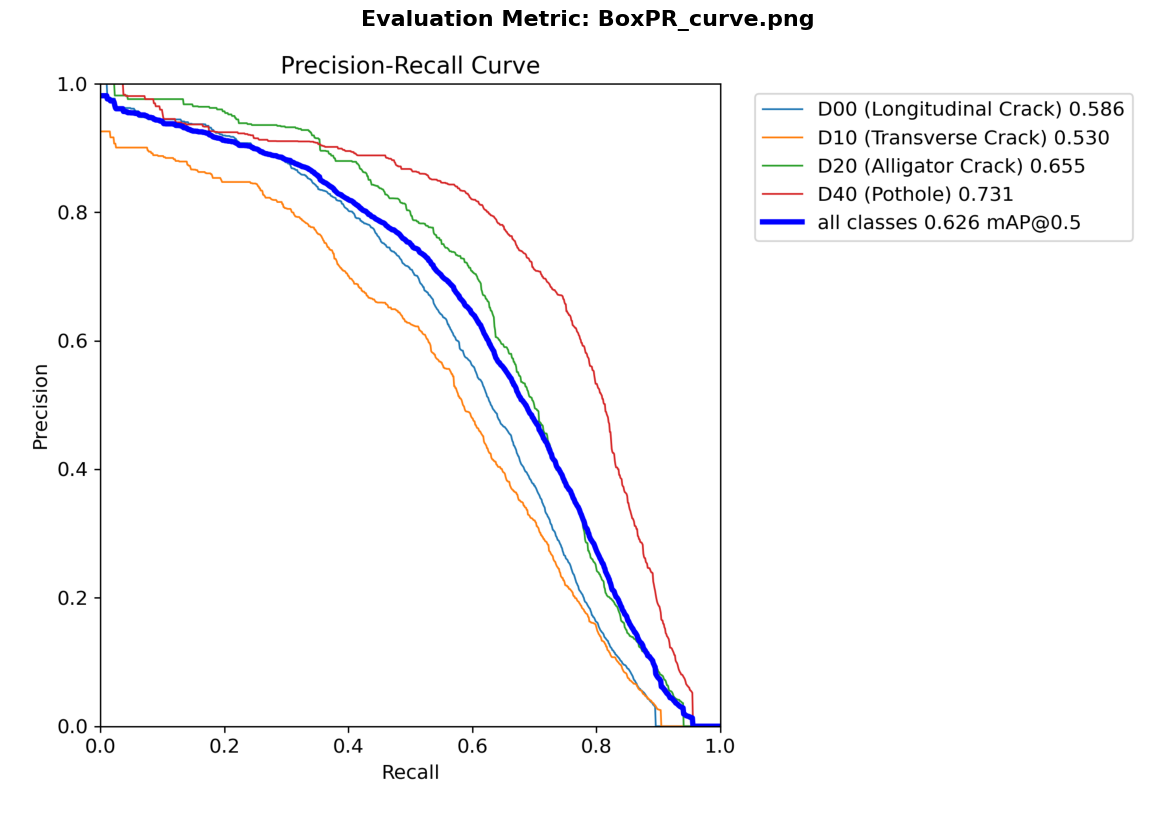

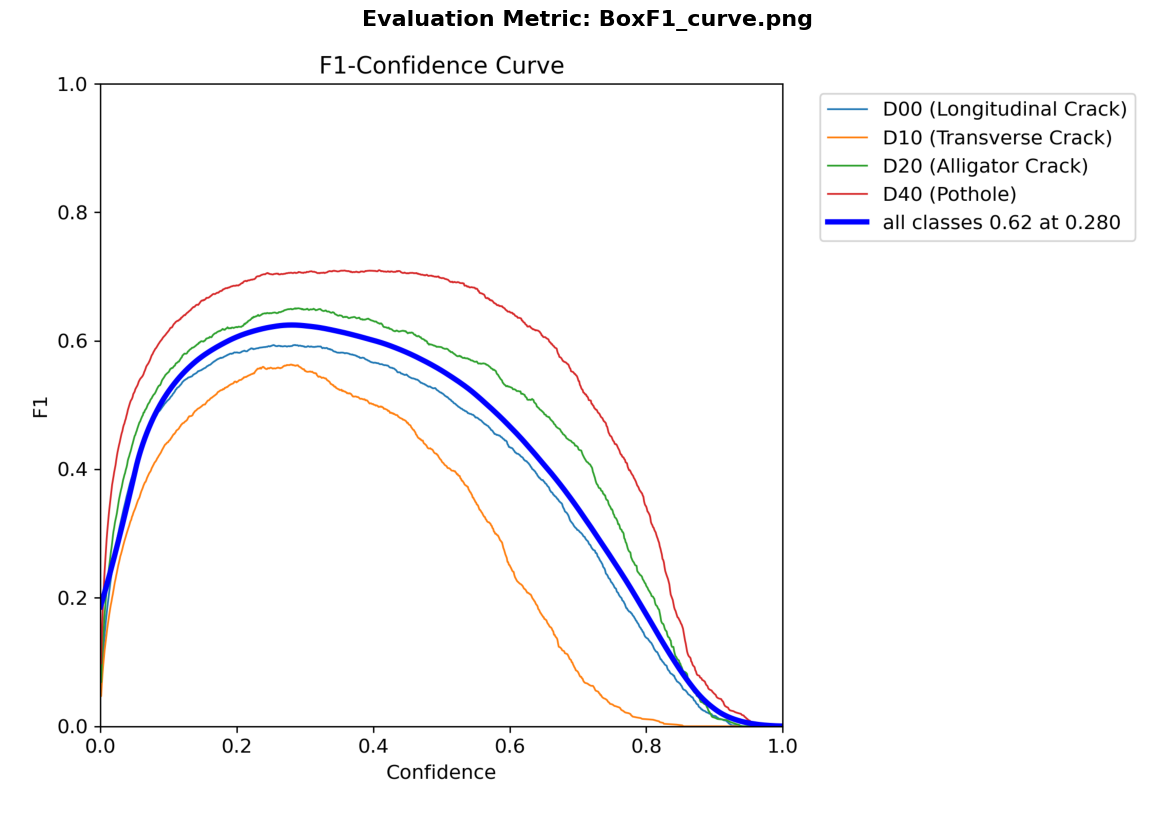

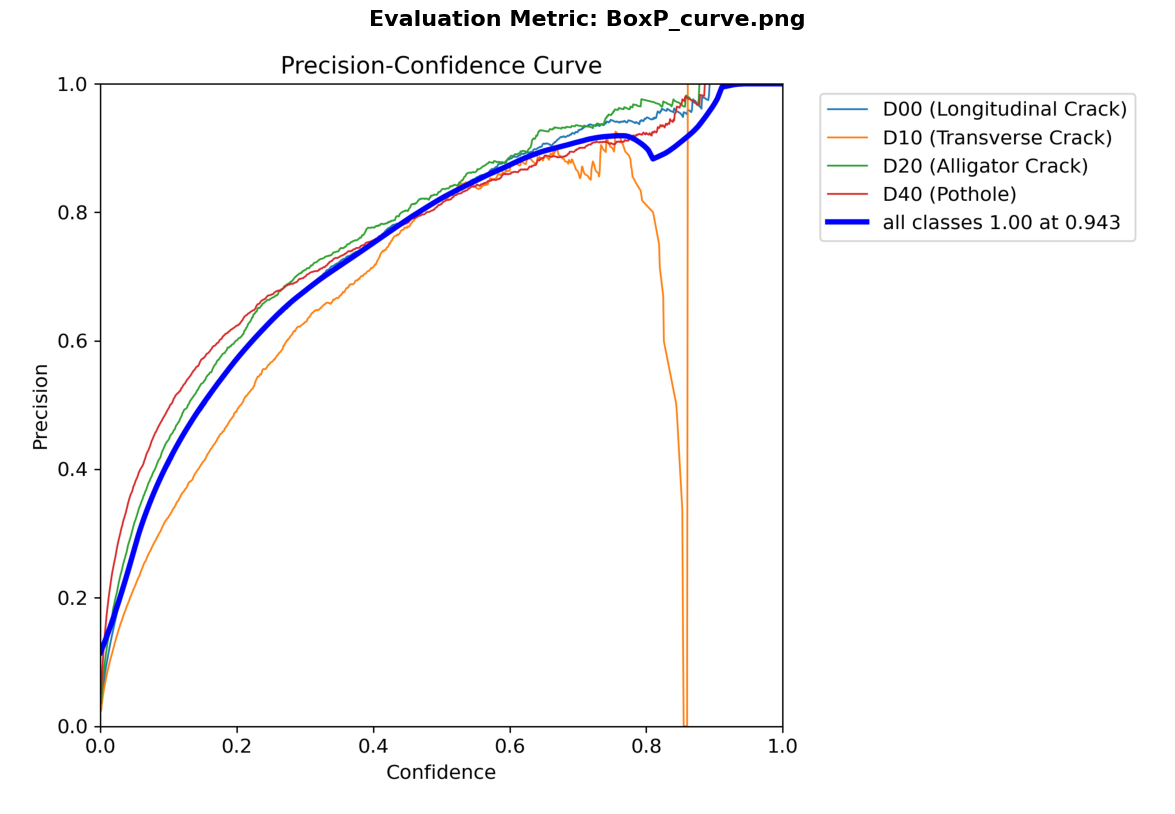

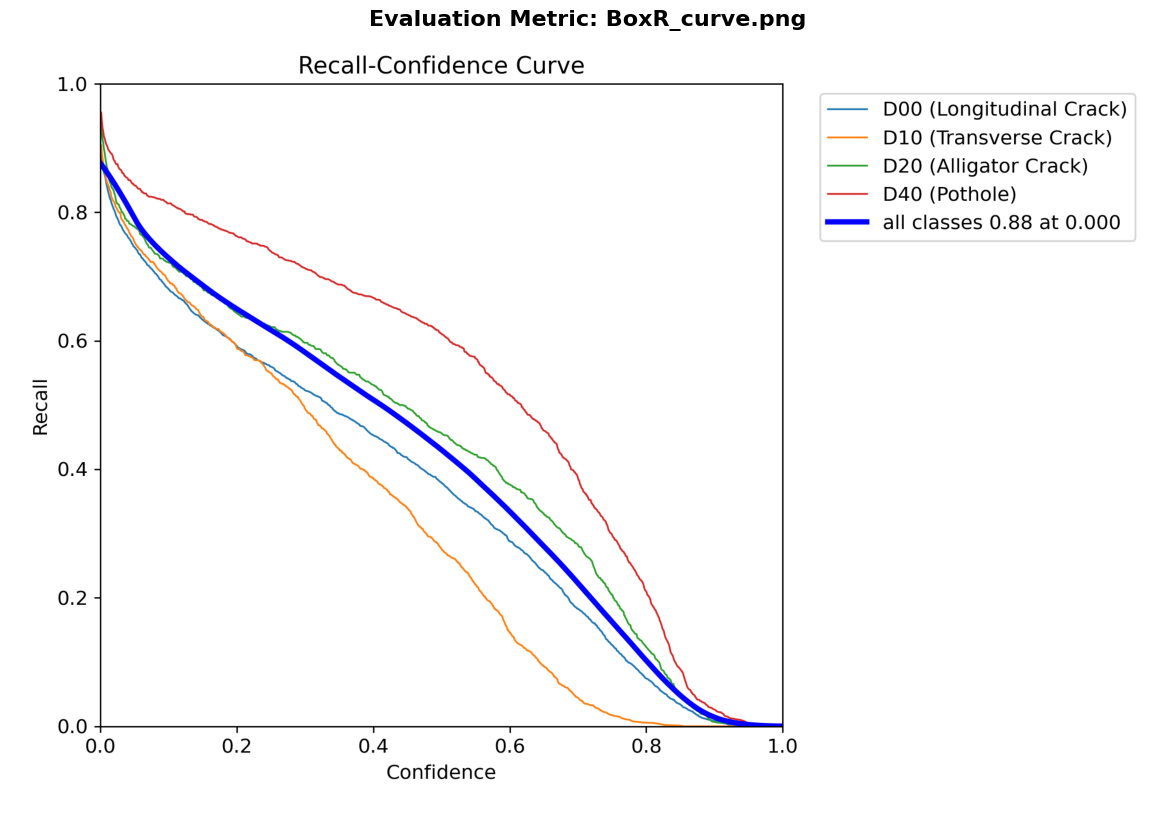

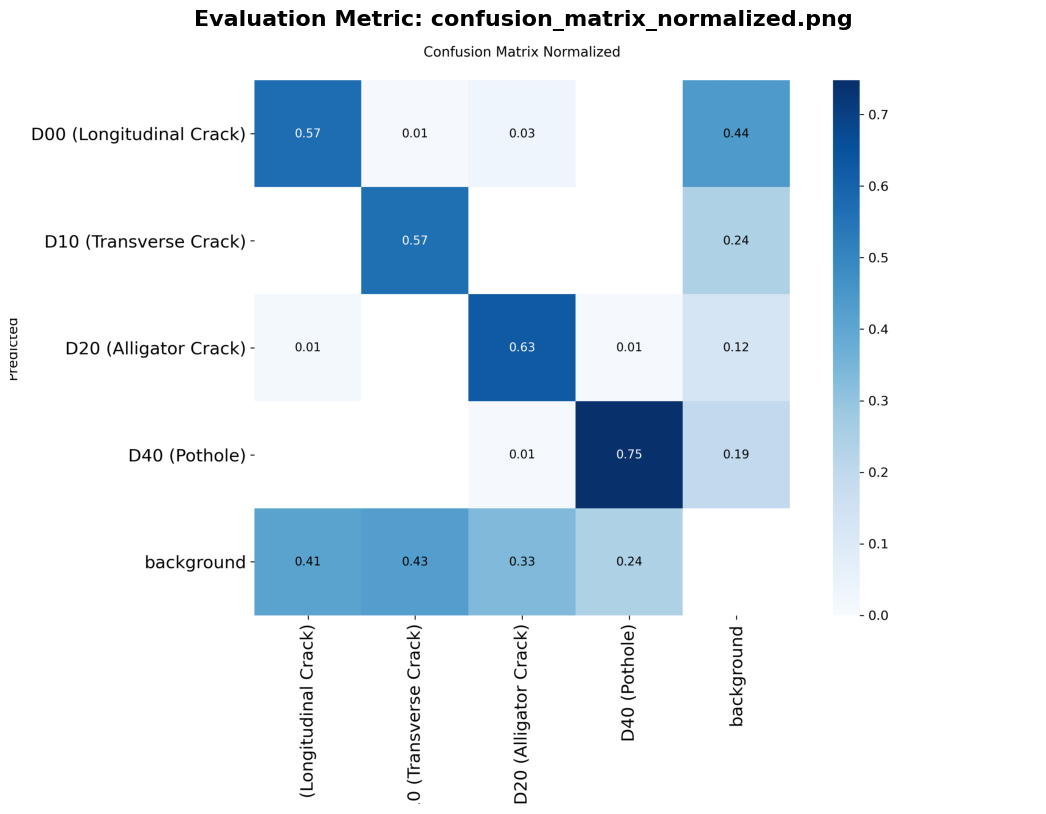

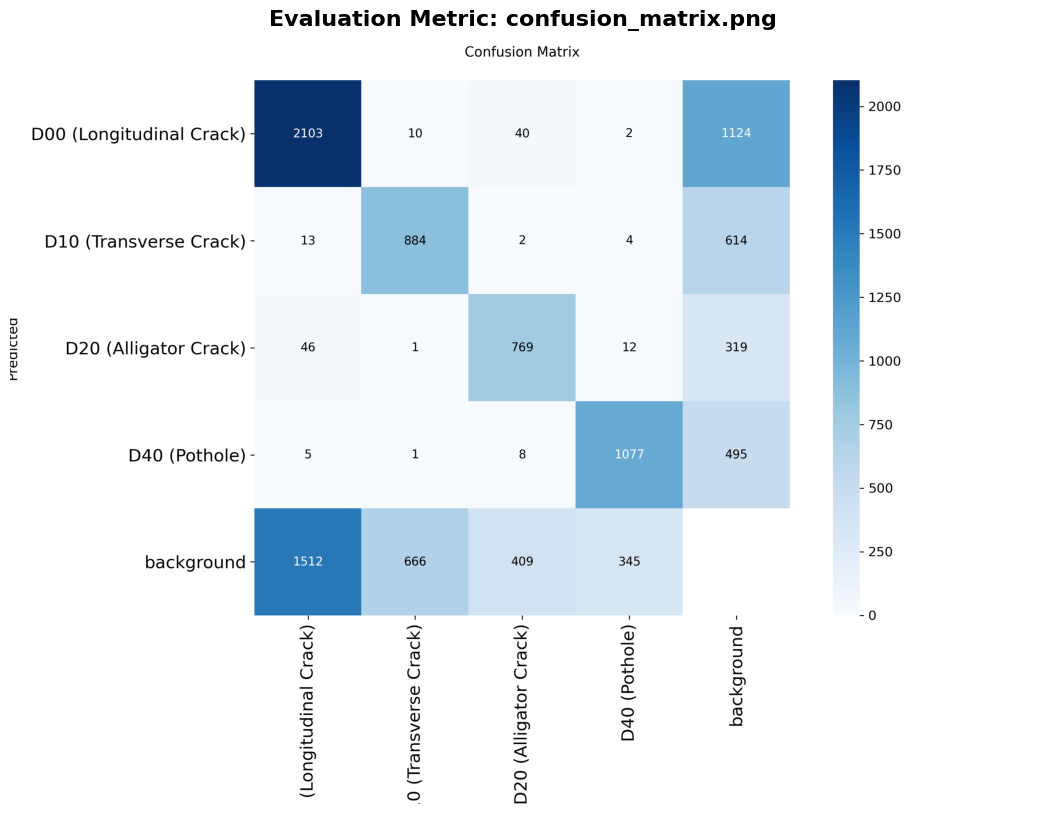

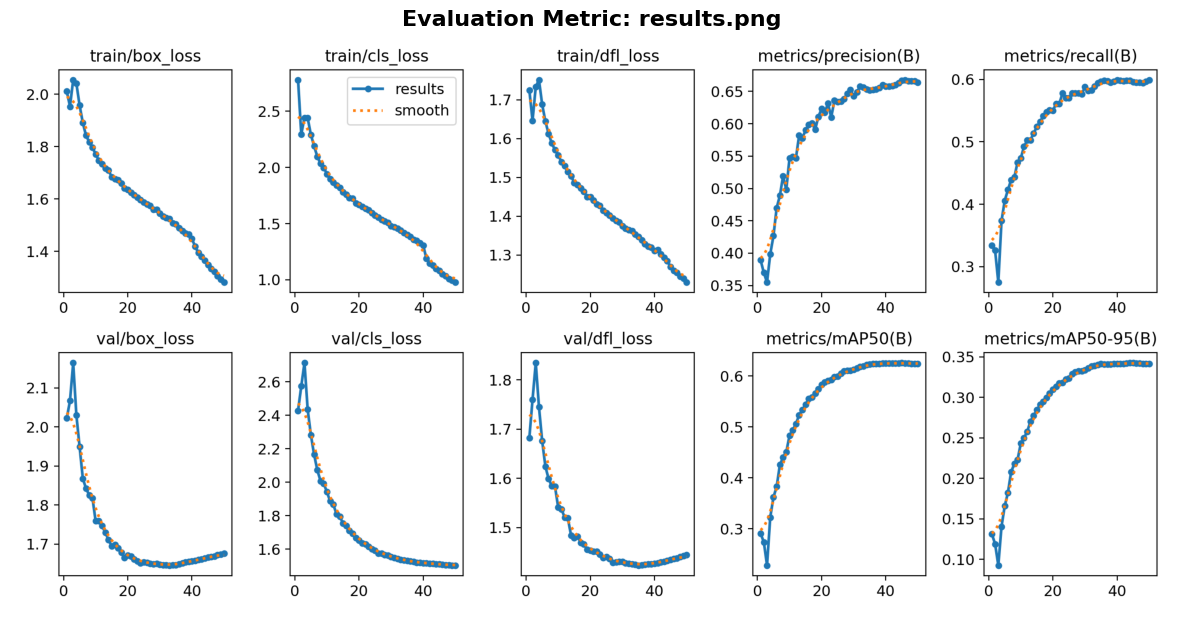

In [11]:
# ==========================================
# CELL 4: FETCH ALL EVALUATION CHARTS
# ==========================================
import os
import glob
import matplotlib.pyplot as plt
import cv2

print("📊 FETCHING ALL EVALUATION CHARTS...")

BASE_DIR = '/content/drive/MyDrive/AI4ALL'

try:
    subdirs = [os.path.join(BASE_DIR, d) for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d)) and 'PaveVision' in d]
    RESULTS_DIR = max(subdirs, key=os.path.getmtime)
    print(f"📂 Pulling metrics from: {RESULTS_DIR}\n")
except Exception as e:
    print("❌ Could not find the AI4ALL directory.")
    RESULTS_DIR = ""

if RESULTS_DIR:
    # Find all PNG files in the results directory
    png_files = glob.glob(os.path.join(RESULTS_DIR, '*.png'))

    if not png_files:
        print("⚠️ No PNG charts found.")
    else:
        for img_path in png_files:
            img_name = os.path.basename(img_path)
            # Skip the raw training image collages to only show the data charts
            if 'val_batch' in img_name or 'train_batch' in img_name or 'labels' in img_name:
                continue

            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(15, 10))
            plt.imshow(img_rgb)
            plt.title(f"Evaluation Metric: {img_name}", fontsize=16, fontweight='bold')
            plt.axis('off')
            plt.show()

🧠 Loading PaveVision AI...
🔍 Scanning image for structural damage...

image 1/1 /content/MICHIGANPOTHOLESPHOTOCAPITOL-1170x878.jpg: 480x640 1 D20 (Alligator Crack), 1 D40 (Pothole), 13.4ms
Speed: 2.2ms preprocess, 13.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
✅ Analysis Complete! Opening visualizer...


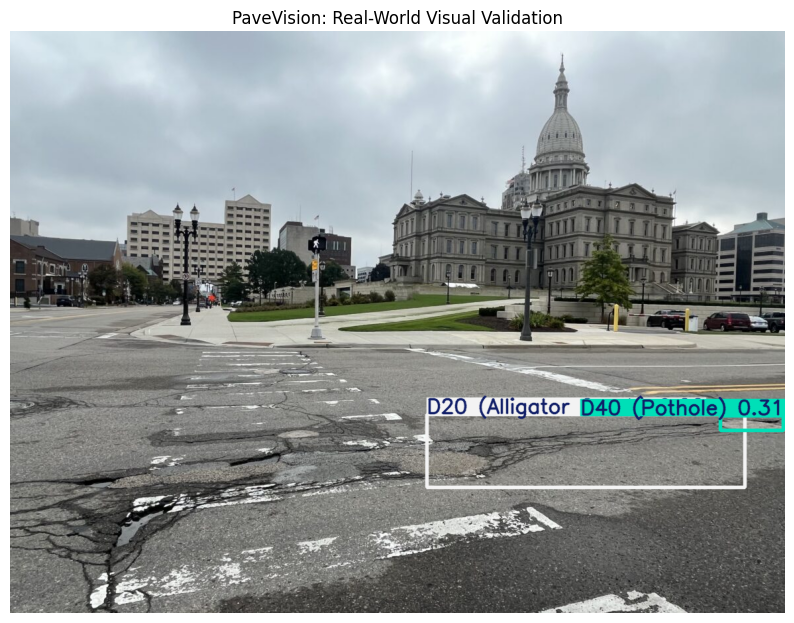

In [22]:
!pip install -q ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

print("🧠 Loading PaveVision AI...")
# Load your trained weights
model = YOLO('/content/drive/MyDrive/AI4ALL/PaveVision_v2-2/weights/best.pt')

print("🔍 Scanning image for structural damage...")
# Run the AI on your random Google image
# conf=0.3 means we only want to see boxes where the AI is at least 30% confident
results = model.predict('MICHIGANPOTHOLESPHOTOCAPITOL-1170x878.jpg', conf=0.13)

# Extract the image with the bounding boxes drawn on it
plotted_img = results[0].plot()

# OpenCV uses BGR colors, Matplotlib uses RGB. We convert it so it looks normal.
final_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

print("✅ Analysis Complete! Opening visualizer...")
# Display the image!
plt.figure(figsize=(10, 8))
plt.imshow(final_img)
plt.axis('off')
plt.title("PaveVision: Real-World Visual Validation")
plt.show()